In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [25]:
def confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    # Map classes to indices (0 to n-1) if they aren't already
    label_to_idx = {val: i for i, val in enumerate(classes)}
    
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[t], label_to_idx[p]] += 1
    return cm

def accuracy_score(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

def get_per_class_stats(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    precisions = []
    recalls = []

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        precisions.append(p)
        recalls.append(r)
        
    return np.array(precisions), np.array(recalls)

def precision_score(y_true, y_pred, average='macro'):
    precisions, _ = get_per_class_stats(y_true, y_pred)
    return np.mean(precisions) if average == 'macro' else None

def recall_score(y_true, y_pred, average='macro'):
    _, recalls = get_per_class_stats(y_true, y_pred)
    return np.mean(recalls) if average == 'macro' else None

def f1_score(y_true, y_pred, average='macro'):
    p_list, r_list = get_per_class_stats(y_true, y_pred)
    f1_list = []
    for p, r in zip(p_list, r_list):
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
        f1_list.append(f1)
    return np.mean(f1_list) if average == 'macro' else None

In [26]:
df = pd.read_csv("obesity_data.csv")

In [27]:
df.describe()

,Age,Height,Weight,BMI,PhysicalActivityLevel
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.857000,170.052417,71.205769,24.888317,2.534000
std,18.114267,10.309971,15.509849,6.193912,1.116284
min,18.000000,136.115719,26.065730,8.470572,1.000000
25%,35.000000,163.514205,61.129629,20.918068,2.000000
50%,50.000000,169.801665,71.929072,24.698647,3.000000
75%,66.000000,177.353596,81.133746,28.732132,4.000000
max,79.000000,201.419670,118.907366,50.791898,4.000000


In [28]:
df.head()

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,56,Male,173.575262,71.982051,23.891783,4,Normal weight
1,69,Male,164.127306,89.959256,33.395209,2,Obese
2,46,Female,168.072202,72.930629,25.817737,4,Overweight
3,32,Male,168.459633,84.886912,29.912247,3,Overweight
4,60,Male,183.568568,69.038945,20.487903,3,Normal weight


In [29]:
df.isnull().sum()

Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64

In [30]:
X = df[['Age','Gender','Height','Weight','BMI','PhysicalActivityLevel']].copy()
y = df['ObesityCategory']

# encode gender
X['Gender'] = LabelEncoder().fit_transform(X['Gender'])

# encode target
le = LabelEncoder()
y = le.fit_transform(y)

# one-hot
y_onehot = np.eye(4)[y]

# normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y_onehot,test_size=0.2,random_state=42)

In [32]:
# Activation Functions
def relu(x):
    return np.maximum(0,x)

def relu_deriv(x):
    return (x>0).astype(float)

def softmax(x):
    exp = np.exp(x - np.max(x,axis=1,keepdims=True))
    return exp/np.sum(exp,axis=1,keepdims=True)

In [33]:
# Loss Functions
def mse(y_true,y_pred):
    return np.mean((y_true-y_pred)**2)

def mse_grad(y_true,y_pred):
    return (y_pred-y_true)/y_true.shape[0]

def cce(y_true,y_pred):
    eps=1e-9
    return -np.mean(np.sum(y_true*np.log(y_pred+eps),axis=1))

def cce_grad(y_true,y_pred):
    return (y_pred-y_true)/y_true.shape[0]

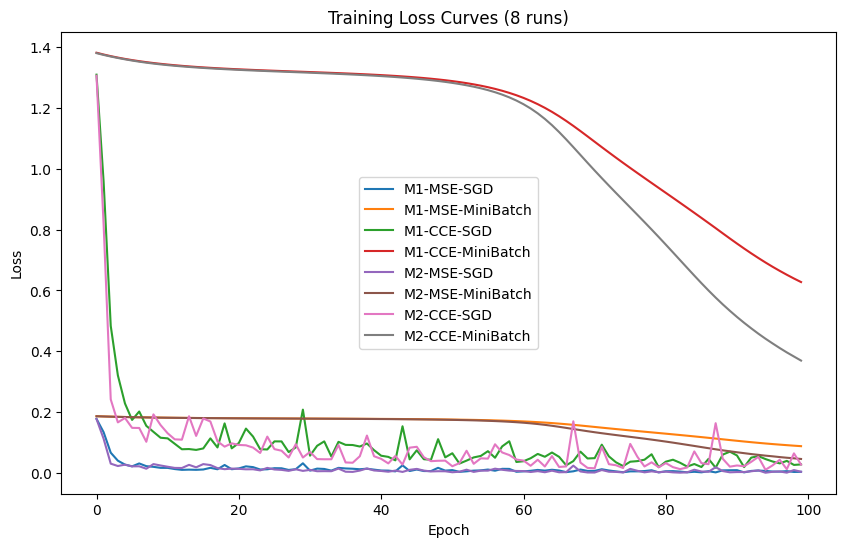

In [34]:
# Neural Network Class
class NeuralNetwork:

    def __init__(self,layers,lr=0.01):
        self.layers = layers
        self.lr = lr
        self.W=[]
        self.b=[]
        np.random.seed(0)
        for i in range(len(layers)-1):
            self.W.append(np.random.randn(layers[i],layers[i+1])*0.1)
            self.b.append(np.zeros((1,layers[i+1])))

    def forward(self,X):

        self.Z=[]
        self.A=[X]

        for i in range(len(self.W)-1):

            z = self.A[-1]@self.W[i]+self.b[i]
            a = relu(z)

            self.Z.append(z)
            self.A.append(a)

        z = self.A[-1]@self.W[-1]+self.b[-1]
        a = softmax(z)

        self.Z.append(z)
        self.A.append(a)

        return a

    def backward(self,y_true,loss_grad):

        dA = loss_grad

        for i in reversed(range(len(self.W))):

            dZ = dA

            if i!=len(self.W)-1:
                dZ = dA * relu_deriv(self.Z[i])

            dW = self.A[i].T@dZ
            db = np.sum(dZ,axis=0,keepdims=True)

            dA = dZ@self.W[i].T

            self.W[i] -= self.lr*dW
            self.b[i] -= self.lr*db

# Training Function
def train(model,X,y,loss_fn,grad_fn,batch_size,epochs=100):

    losses=[]

    for epoch in range(epochs):

        perm = np.random.permutation(len(X))
        X=X[perm]
        y=y[perm]

        for i in range(0,len(X),batch_size):

            xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]

            pred = model.forward(xb)

            grad = grad_fn(yb,pred)

            model.backward(yb,grad)

        loss = loss_fn(y,model.forward(X))
        losses.append(loss)

    return losses

# Model Architectures
M1_arch = [6,64,32,16,4]
M2_arch = [6,128,64,32,16,4]

runs = []
results=[]

configs = [
("M1","MSE","SGD",M1_arch,mse,mse_grad,1),
("M1","MSE","MiniBatch",M1_arch,mse,mse_grad,40),
("M1","CCE","SGD",M1_arch,cce,cce_grad,1),
("M1","CCE","MiniBatch",M1_arch,cce,cce_grad,40),

("M2","MSE","SGD",M2_arch,mse,mse_grad,1),
("M2","MSE","MiniBatch",M2_arch,mse,mse_grad,40),
("M2","CCE","SGD",M2_arch,cce,cce_grad,1),
("M2","CCE","MiniBatch",M2_arch,cce,cce_grad,40)
]

# Run Experiments
for name,loss_name,opt,arch,loss_fn,grad_fn,bs in configs:

    model = NeuralNetwork(arch)

    losses = train(model,X_train,y_train,loss_fn,grad_fn,bs)

    runs.append((name,loss_name,opt,losses))

    preds = model.forward(X_test)
    preds = np.argmax(preds,axis=1)

    y_true = np.argmax(y_test,axis=1)

    acc = accuracy_score(y_true,preds)
    prec = precision_score(y_true,preds,average='macro')
    rec = recall_score(y_true,preds,average='macro')
    f1 = f1_score(y_true,preds,average='macro')

    results.append([name,loss_name,opt,acc,prec,rec,f1])

# Loss Curves
plt.figure(figsize=(10,6))

for r in runs:
    label=f"{r[0]}-{r[1]}-{r[2]}"
    plt.plot(r[3],label=label)

plt.legend()
plt.title("Training Loss Curves (8 runs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [35]:
# Performance Table
results_df = pd.DataFrame(results,columns=[
"Model","Loss","Optimizer","Accuracy","Precision","Recall","F1"])

print(results_df)

# Best Model Confusion Matrix
best = results_df.sort_values("Accuracy",ascending=False).iloc[0]

print("\nBest configuration:\n",best)

# retrain best
for c in configs:
    if c[0]==best.Model and c[1]==best.Loss and c[2]==best.Optimizer:
        arch,loss_fn,grad_fn,bs = c[3],c[4],c[5],c[6]

model = NeuralNetwork(arch)
train(model,X_train,y_train,loss_fn,grad_fn,bs)

preds = np.argmax(model.forward(X_test),axis=1)
y_true = np.argmax(y_test,axis=1)

cm = confusion_matrix(y_true,preds)

print("\nConfusion Matrix:")
print(cm)

  Model Loss  Optimizer  Accuracy  Precision    Recall        F1
0    M1  MSE        SGD     0.955   0.959047  0.958322  0.958562
1    M1  MSE  MiniBatch     0.825   0.860743  0.827419  0.811938
2    M1  CCE        SGD     0.955   0.959047  0.958322  0.958562
3    M1  CCE  MiniBatch     0.825   0.860743  0.827419  0.811938
4    M2  MSE        SGD     0.960   0.955652  0.970353  0.962317
5    M2  MSE  MiniBatch     0.940   0.954806  0.924318  0.934372
6    M2  CCE        SGD     0.960   0.955652  0.970353  0.962317
7    M2  CCE  MiniBatch     0.940   0.954806  0.924318  0.934372

Best configuration:
 Model              M2
Loss              CCE
Optimizer         SGD
Accuracy         0.96
Precision    0.955652
Recall       0.970353
F1           0.962317
Name: 6, dtype: object

Confusion Matrix:
[[69  0  2  1]
 [ 0 32  0  0]
 [ 2  3 60  0]
 [ 0  0  0 31]]
